In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["GRB_LICENSE_FILE"] = "/usr0/home/naveenr/gurobi.lic"
os.environ['MKL_THREADING_LAYER'] = "GNU"

In [3]:
from concept_abstraction.training import *
from concept_abstraction.selection import *
from concept_abstraction.concept_bank import *
from concept_abstraction.env_utils import *
from concept_abstraction.environments import *
from concept_abstraction.utils import *
from concept_abstraction.environments import ConceptEnv
import sys 
import argparse
import secrets
import numpy as np 
import random 
import os
from stable_baselines3 import PPO
import pickle
import resource

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [4]:
is_jupyter = 'ipykernel' in sys.modules
is_main = __name__ == "__main__"

In [5]:
if is_main:
    if is_jupyter: 
        # Basics 
        seed        = 42
        environment_string = "cart_pole"
        gold_timesteps =10
        training_timesteps = 10
        num_concepts_selected = 3
        selection_function = "q_value"
        # Experiment #1 & #2
        run_basic = False
        run_iterative = False 
        run_two_stage = True   
        run_imperfect=False 
        run_intervention=False 
        # Experiment #3
        cbm_accuracy_by_concept = None 
        intervention_probability = 0
        intervention_accuracy_by_concept = None 
        cbm_std_by_concept = None 
        target_abstraction = 0.05
        reward_error = 0
        # Experiment #4
        concept_source = "human_selected_binary"
        # Experiment #5
        assess_completeness=False
        # Experiment #6
        num_iterations = 0
        selections_per_round = 0
        initial_concepts = 0
        out_folder = "llm"
    else:
        parser = argparse.ArgumentParser()
        parser.add_argument('--seed', help='Random Seed', type=int, default=42)
        parser.add_argument('--environment_string', help='Which environment to create', type=str, default="tree")
        parser.add_argument('--training_timesteps', help='Number of training timesteps', type=int, default=10000)
        parser.add_argument('--gold_timesteps', help='Number of training timesteps without concepts', type=int, default=10000)
        parser.add_argument('--num_concepts_selected', help='Number of concepts selected by greedy or random',type=int, default=0)
        parser.add_argument('--selection_function', help='When selecting, use q_value, policy, or transition?', type=str, default="policy")
        parser.add_argument('--cbm_accuracy_by_concept', help="What is the accuracy of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--intervention_accuracy_by_concept', help="What is the accuracy of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--cbm_std_by_concept', help="What is the error of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--run_two_stage', help='Run the two stage?', action='store_true')
        parser.add_argument('--run_iterative', help='Run the iterative?', action='store_true')
        parser.add_argument('--run_intervention', help='Run the intervention?', action='store_true')
        parser.add_argument('--run_basic', help='Run the basic comparisons?', action='store_true')
        parser.add_argument('--run_imperfect', help='Run the imperfect comparisons?', action='store_true')
        parser.add_argument('--intervention_probability', help='Value for the target abstraction with human performance', type=float, default=0.05)
        parser.add_argument('--target_abstraction', help='Value for the target abstraction with human performance', type=float, default=0.05)
        parser.add_argument('--reward_error', help="How much to perturb the reward by?", type=float, default=0)
        parser.add_argument('--concept_source', help='When selecting, use q_value, policy, or transition?', type=str, default="human_selected")
        parser.add_argument('--assess_completeness', help='Compare to the concept completeness algorithm?', action='store_true')
        parser.add_argument('--num_iterations', help='Number of iterations for iterative algorithms',type=int, default=0)
        parser.add_argument('--selections_per_round', help='Concepts to select per round',type=int, default=0)
        parser.add_argument('--initial_concepts', help='Number of starting/initial concepts',type=int, default=0)
        parser.add_argument('--out_folder', help='Which folder', type=str, default="exploration")

        args = parser.parse_args()

        seed = args.seed
        environment_string = args.environment_string
        training_timesteps = args.training_timesteps 
        gold_timesteps = args.gold_timesteps
        num_concepts_selected = args.num_concepts_selected
        selection_function = args.selection_function
        cbm_accuracy_by_concept = args.cbm_accuracy_by_concept
        cbm_std_by_concept = args.cbm_std_by_concept
        run_basic = args.run_basic
        run_iterative = args.run_iterative
        run_two_stage = args.run_two_stage
        run_imperfect = args.run_imperfect
        run_intervention = args.run_intervention
        intervention_probability = args.intervention_probability
        intervention_accuracy_by_concept = args.intervention_accuracy_by_concept
        target_abstraction = args.target_abstraction
        reward_error = args.reward_error
        concept_source = args.concept_source
        assess_completeness = args.assess_completeness
        num_iterations = args.num_iterations 
        selections_per_round = args.selections_per_round
        initial_concepts = args.initial_concepts
        out_folder = args.out_folder

    save_name = secrets.token_hex(4)  

In [6]:
if is_main:
        results = {}
        results['parameters'] = {'seed'      : seed,
                'environment_string'    : environment_string, 
                'training_timesteps': training_timesteps, 
                'gold_timesteps': gold_timesteps,
                'selection_function': selection_function,
                'num_concepts_selected': num_concepts_selected,
                'cbm_accuracy_by_concept': cbm_accuracy_by_concept,
                'cbm_std_by_concept': cbm_std_by_concept,
                'intervention_probability': intervention_probability,
                'intervention_accuracy_by_concept': intervention_accuracy_by_concept,
                'target_abstraction': target_abstraction,
                'reward_error': reward_error, 
                'concept_source': concept_source,
                'assess_completeness': assess_completeness,
                'num_iterations': num_iterations,
                'selections_per_round': selections_per_round, 
                'initial_concepts': initial_concepts,
                'run_basic': run_basic,
                'run_iterative': run_iterative, 
                'run_two_stage': run_two_stage, 
                'run_intervention': run_intervention,
                'run_imperfect': run_imperfect, 
        }
        print("Parameters {}".format(results['parameters']))

Parameters {'seed': 42, 'environment_string': 'cart_pole', 'training_timesteps': 10, 'gold_timesteps': 10, 'selection_function': 'q_value', 'num_concepts_selected': 3, 'cbm_accuracy_by_concept': None, 'cbm_std_by_concept': None, 'intervention_probability': 0, 'intervention_accuracy_by_concept': None, 'target_abstraction': 0.05, 'reward_error': 0, 'concept_source': 'human_selected_binary', 'assess_completeness': False, 'num_iterations': 0, 'selections_per_round': 0, 'initial_concepts': 0, 'run_basic': False, 'run_iterative': False, 'run_two_stage': True, 'run_intervention': False, 'run_imperfect': False}


In [7]:
if is_main:
    np.random.seed(seed)
    random.seed(seed)

### Basic Setup

In [10]:
concep

NameError: name 'concept_list' is not defined

In [8]:
every_data_point = 5

In [14]:
if is_main:
    concept_list = get_concepts(environment_string,"human_selected_binary",seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))
    ground_truth_env, ground_truth_gym_env, additional_info = get_environment(environment_string, None, seed)   
    model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
    if os.path.exists(model_name):
        groundtruth_model = PPO.load(model_name)
    # else:
    #     policy = "CnnPolicy"
    #     groundtruth_model = train_ppo_model(ground_truth_env,environment_string,total_timesteps=gold_timesteps,policy=policy)
    #     groundtruth_model.save(model_name)



/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [21]:
groundtruth_reward = evaluate_model(environment_string,ground_truth_gym_env,additional_info,groundtruth_model,seed)

In [22]:
groundtruth_reward

25.9578125

In [12]:
model_name = "../../results/models/concept_predictor_env={}_training={}_seed={}.pth".format(environment_string,100,seed)

height = width = 84

if environment_string == "mini_grid":
    num_frames = 1
else:
    num_frames = 4

if environment_string == "cart_pole":
    height = 160
    width = 240

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if os.path.exists(model_name):
    concept_predictor = ConceptPredictorCNN(len(concept_list), num_frames=num_frames,height=height,width=width).to(device)
    concept_predictor.load_state_dict(torch.load(model_name, weights_only=True))
    concept_predictor.eval()
else:
    concept_predictor, acc_list = train_concept_predictor(ground_truth_gym_env,groundtruth_model,concept_list,list(range(len(concept_list))),environment_string,epochs=25,max_episode_length=10_000)
    torch.save(concept_predictor.state_dict(), model_name)
    concept_predictor.eval()



In [15]:
acc_list = evaluate_concept_predictor(concept_predictor,ground_truth_gym_env,groundtruth_model,concept_list)

Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration 8000/10000
Iteration 9000/10000
Iteration 10000/10000
Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration 8000/10000
Iteration 9000/10000
Iteration 10000/10000
Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration 8000/10000
Iteration 9000/10000
Iteration 10000/10000
Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration 8000/10000
Iteration 9000/10000
Iteration 10000/10000
Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration

In [32]:
concept_predictor

ConceptPredictorCNN(
  (feature_extractor): NatureCNN(
    (cnn): Sequential(
      (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (5): ReLU()
      (6): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=26624, out_features=512, bias=True)
      (1): ReLU()
    )
  )
  (classifier): Linear(in_features=512, out_features=12, bias=True)
)

In [10]:
concept_predictor = concept_predictor.cuda()
concept_predictor.eval()

# Warmup to allocate memory
dummy_input = torch.zeros(8, num_frames, height, width, device='cuda')
with torch.no_grad():
    _ = concept_predictor(dummy_input)



In [16]:
model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,seed,"q_value","human_selected_binary")
if os.path.exists(model_name):
    q_estimates = pickle.load(open(model_name,"rb"))
else:
    q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list)
    pickle.dump(q_estimates,open(model_name,"wb"))


In [17]:
unique_actions = list(set([int(i[1]) for i in q_estimates]))
actions = np.array([i[1] for i in q_estimates])

# Continuous
if concept_source == "human_selected":
    all_concepts = np.array([i[0] for i in q_estimates])
    median_by_column = np.median(all_concepts,axis=0)
    discretized_X = (all_concepts < median_by_column).astype(np.int8)
else:
    discretized_X = np.array([i[0] for i in q_estimates])

if selection_function == "q_value":
    q_values = np.array([i[2] for i in q_estimates])

    final_vals = []
    seen = set()
    for a in unique_actions:
        relevant_idx = np.where(actions == a)[0]
        if len(relevant_idx) <= 500:
            relevant_low = relevant_high = relevant_idx
        else:
            relevant_low = np.argsort(np.abs(q_values))[:500]
            relevant_high = np.argsort(np.abs(q_values))[-500:]
        for low_idx in relevant_low:
            for high_idx in relevant_high:
                diff = abs(q_values[low_idx] - q_values[high_idx])
                # tuple of differing concept indices
                diffs = tuple(i for i, (l, h) in enumerate(zip(discretized_X[low_idx], discretized_X[high_idx])) if l != h)
                tup = (diff, diffs)
                if diffs not in seen and diffs != ():
                    seen.add(diffs)
                    final_vals.append(tup)
    final_vals = sorted(final_vals,reverse=True)

In [18]:
def get_score(final_vals,idx):
    for j in final_vals:
        if set(j[1]).intersection(set(idx)) == set([]):
            break 
    else:
        return 0
    return j[0]

In [20]:
get_score(final_vals,list(range(len(concept_list))))

0

In [21]:
import itertools 

In [22]:
intervention_prob = 0.5

In [23]:
def get_score(final_vals,idx):
    for j in final_vals:
        if set(j[1]).intersection(set(idx)) == set([]):
            break 
    else:
        return 0
    return j[0]

# Compute pairs of accuracy x score
all_pairs = []

for combo in itertools.combinations(range(len(concept_list)), num_concepts_selected):
    average_accuracy = float(np.mean([acc_list[i] for i in combo]))
    score = float(get_score(final_vals,combo))
    all_pairs.append((average_accuracy,score))
results['no_intervention'] = all_pairs 


all_pairs_intervention = []

for combo in itertools.combinations(range(len(concept_list)), num_concepts_selected):
    average_accuracy = float(np.mean([acc_list[i] for i in combo]))*(1-intervention_prob) + intervention_prob
    score = float(get_score(final_vals,combo))
    all_pairs_intervention.append((average_accuracy,score))
results['intervention'] = all_pairs_intervention


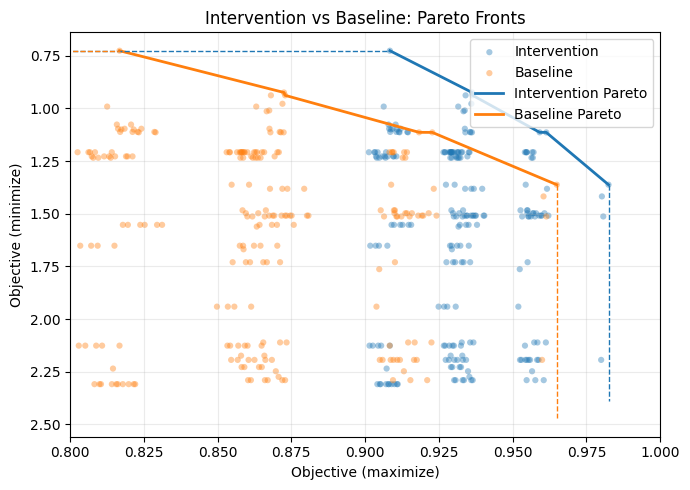

In [35]:
import numpy as np
import matplotlib.pyplot as plt

intervention = np.array(results['intervention'])
baseline = np.array(results['no_intervention'])

plt.figure(figsize=(7,5))

# ----------------------------------------------------
# Scatter plots (soft)
# ----------------------------------------------------
plt.scatter(
    intervention[:,0], intervention[:,1],
    s=20, alpha=0.4, edgecolors='none', label='Intervention'
)
plt.scatter(
    baseline[:,0], baseline[:,1],
    s=20, alpha=0.4, edgecolors='none', label='Baseline'
)

# ----------------------------------------------------
# Pareto front (maximize x, minimize y)
# ----------------------------------------------------
def pareto_front(points):
    # Sort by x descending (maximize x)
    pts = points[points[:,0].argsort()[::-1]]
    front = [pts[0]]
    for p in pts[1:]:
        if p[1] <= front[-1][1]:  # minimize y
            front.append(p)
    return np.array(front)

intervention_pf = pareto_front(intervention)
baseline_pf     = pareto_front(baseline)

plt.plot(intervention_pf[:,0], intervention_pf[:,1],
         linewidth=2, label='Intervention Pareto')
plt.plot(baseline_pf[:,0], baseline_pf[:,1],
         linewidth=2, label='Baseline Pareto')

# ----------------------------------------------------
# Extend fronts to axes
# ----------------------------------------------------
def extend_to_axes(front, color, y_max=None):
    ax = plt.gca()

    # get max y after all plotting is done if not provided
    if y_max is None:
        _, y_max = ax.get_ylim()

    # First PF point = largest x
    x0, y0 = front[0]
    # vertical line up to y_max
    plt.plot([x0, x0], [y0, y_max], linestyle='--', linewidth=1, color=color)

    # Last PF point = smallest y
    x1, y1 = front[-1]
    # horizontal line to x=0
    plt.plot([0, x1], [y1, y1], linestyle='--', linewidth=1, color=color)

# Add axis extension lines
extend_to_axes(intervention_pf, color='tab:blue')
extend_to_axes(baseline_pf,      color='tab:orange')

# ----------------------------------------------------
# Flip y-axis (because lower is better)
# ----------------------------------------------------
plt.gca().invert_yaxis()
plt.xlim([0.8,1])

# ----------------------------------------------------
# Labels and style
# ----------------------------------------------------
plt.xlabel("Objective (maximize)")
plt.ylabel("Objective (minimize)")
plt.title("Intervention vs Baseline: Pareto Fronts")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()


In [36]:
training_timesteps=100_000

In [37]:
all_combos = list(itertools.combinations(range(len(concept_list)), num_concepts_selected))
sampled = random.sample(all_combos, 2)
sampled.append(lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates,"human_selected_binary")[1])

results['lp'] = {'combos': sampled, 'scores': []}

for combo in sampled:
    average_accuracy = float(np.mean([acc_list[i] for i in combo]))
    score = float(get_score(final_vals,combo))
    idx = combo
    subset_concept = [concept_list[i] for i in idx]

    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx)
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_lp".format(environment_string))    
    reward_baseline = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx,intervention_prob=intervention_prob)
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_lp".format(environment_string))    
    reward_intervention = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['lp']['scores'].append({'reward_intervention': reward_intervention, 'reward_baseline': reward_baseline})

Set parameter Username
Set parameter LicenseID to value 2709943
Academic license - for non-commercial use only - expires 2026-09-17


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated



approx_kl,██▆▆▆▄▄▃▃▃▂▂▂▃▃▃▂▂▁▁▂▂▂▂▁▃▃▃▃▂▂▂▂▂▂▁▃▁▁▂
clip_fraction,███▄▄▃▃▂▂▂▂▁▁▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▂▂▂▂▂▂▁▁▁▂▁▃
ema_norm_reward,▁▁▁▂▁▂▂▂▃▃▄▅▄▆▇▆▅▇▆▇▆▆▇▆▇▇▆▇▆▆▆▆▆▇▇▇▇▇█▆
entropy_loss,▁▁▁▁▁▂▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇████
episode_length_mean,▁▁▁▁▂▁▁▂▂▁▁▂▃▃▄▄▄▄▅▄▄▅█▄▆▅▆▄▄▆▆▄▆▇▃▄▄▄█▄
episode_reward_max,▁▂▃▂▂▂▁▃▂▃▅▄▁▂▅▅▇▆▃▄▄▆▄▅▂▄█▆▅▅▆▅▆▅▆▅▄▇▅▄
episode_reward_mean,▁▁▁▁▁▂▃▃▃▃▃▃▅▄▃▄▃▄▅▄▅▄▆▄█▆▅▆▄▄▄▄▄▄▄▄▄█▅▃
episode_reward_min,▁▁▁▁▂▄▁▂▁▂▃▃▃▅▃▄▄▄▄▅▅▄▅▅▃█▅▄▂▃▆▄▄▇▅▄▃▅▆▅
episodes_completed,█▆▆█▆▃▆█▆▆▆█▃▁▃▁▁▁▃▁▃▃▁▁▁▆▁▁▁▃▁▃▁▁▁▁▁▁▁▁
explained_variance,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▃▅▅▅▅▆▆▆▇▇▅▅▅▅█
+1,...


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated



approx_kl,█████▇▇▇▇▇▇▄▄▄▄▃▃▃▂▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁
clip_fraction,█▄▄▄▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▂▂▂▂▂▂▁▁▁▁▁▁▁▁
ema_norm_reward,▁▁▁▂▁▂▂▂▂▂▃▂▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▆▅▆▅▅▆▆▇▆█▅▇▆
entropy_loss,▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█
episode_length_mean,▁▁▁▁▁▂▁▂▃▂▃▁▃▂▂▄▂▃▂▃▃▃▃▃▄▃▃▄▂▃▃▃▆▅▃▄▃▃█▅
episode_reward_max,▁▂▂▁▂▃▂▄▃▁▄▁▄▃▃▆▇▂▂▄▂▄▂▅▆▅▄█▇▇▁█▅▄▅▅▃▄▅▄
episode_reward_mean,▁▁▁▂▁▁▃▃▁▃▂▂▁▂▂▂▃▁▂▂▃▅▃▃▄▂▃▃▆▅▄▇▆▅▇█▇███
episode_reward_min,▁▂▁▁▁▁▃▁▁▁▃▁▂▂▂▂▃▂▃▂▂▂▃▂▃▃▄▅▃▄▆▄▅█▄▆▅▄▄▃
episodes_completed,█▇▂▁▂▂▁▁▁▂▄▂▂▁▂▂▂▄▁▁▂▂▂▄▁▁▂▁▁▂▂▁▁▁▁▁▁▁▂▁
explained_variance,▁▁▂▂▂▄▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▇▇▇▆▆▇▇▇▅▆▆▇▇█
+1,...


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated



KeyboardInterrupt: 

In [38]:
results['lp']['scores']

[{'reward_intervention': 117.472553699284,
  'reward_baseline': 107.88888888888889}]

In [40]:
json.dumps(results)

'{"parameters":{"seed":42,"environment_string":"cart_pole","training_timesteps":10,"gold_timesteps":10,"selection_function":"q_value","num_concepts_selected":3,"cbm_accuracy_by_concept":null,"cbm_std_by_concept":null,"intervention_probability":0,"intervention_accuracy_by_concept":null,"target_abstraction":0.05,"reward_error":0,"concept_source":"human_selected_binary","assess_completeness":false,"num_iterations":0,"selections_per_round":0,"initial_concepts":0,"run_basic":false,"run_iterative":false,"run_two_stage":true,"run_intervention":false,"run_imperfect":false},"no_intervention":[[0.9167792961906192,2.1108254194259644],[0.9108808463065858,1.5130627155303955],[0.9150745579638807,1.5130627155303955],[0.9241905969642867,1.5090761184692383],[0.9649318939002075,1.3623554706573486],[0.9613944925553275,1.5130627155303955],[0.9224747348339478,2.1108254194259644],[0.9145712013259693,2.1108254194259644],[0.9097573320429605,1.483790636062622],[0.9141651788445602,1.2083102464675903],[0.8612877

In [16]:
subset_concept, idx = multiple_lp_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates,"human_selected_binary")
idx

[0, 2, 6, 14, 29, 30, 34, 35, 38, 39, 40]

In [14]:
fqe_name = "../../results/models/fqe_env={}_seed={}.pth".format(environment_string,seed)
env, eval_env, additional_info = get_environment(environment_string,concept_list,seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=list(range(len(concept_list))))
optimal_model = train_ppo_model(env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_optimal".format(environment_string))    

if os.path.exists(fqe_name):
    fqe, states, state_mean, state_std, q_values  = load_fqe(fqe_name, eval_env, optimal_model)
else:
    fqe,states, state_mean, state_std, q_values = train_fqe(eval_env,optimal_model)  
    save_fqe(fqe,fqe_name)


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

ema_norm_reward,▁
episode_length_mean,▁
episode_reward_max,▁
episode_reward_mean,▁
episode_reward_min,▁
episodes_completed,▁
ema_norm_reward,0.09752
episode_length_mean,135
episode_reward_max,0.5284
episode_reward_mean,0.514
episode_reward_min,0.4996


approx_kl,▃▃▄▄▄▁▂▂▂▂▂▄▄▁▅▅▅▅▂▅▅▂▂▇▇▅▅▅▆▆█▆▆▆▆▇▇███
clip_fraction,▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▂▂▁▁▁▂▂▂▃▂▂▂▅▅▅▇▃▃▆▆▅▅▆█▆
ema_norm_reward,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▅▆▇▇▇▇▇██▇█▇███▇█
entropy_loss,▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▄▆▇▇██
episode_length_mean,████████▇██▆███▇█▂▄▄▃▁▅▄▂▆▃▂▆▁▁▂█▂▄▁▁▂▂▂
episode_reward_max,▁▁▁▁▁▃▁▁▁▁▁▁▁▂▁▁▃▁▁▄▁▃▅▁▆▁█▇██▄█▇▇██▇▇██
episode_reward_mean,▁▁▄▁▁▁▁▁▁▁▁▁▃▁█▅▅▆▇▇▅▇███▅▇▇▅█▆▆██▇█▅███
episode_reward_min,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▄▁▇█▆█▆█▅█▅▁▇▇▅▇█
episodes_completed,▃█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▁▁▁▁▁▃▁▁▃▁▃▁▃▁▁▁▃
explained_variance,▁▅▅▅▅▆▆▄▅▄▃▂▂▂▄▄▄▄▄▄▃▄▄▄▄▅▅▆▇▇▇▇▇▇██████
+1,...


Created FQE with 5 ensemble members on cuda
State dim: 44, Action dim: 7
  Collected 800/5000 transitions (step 100)
  Collected 1600/5000 transitions (step 200)
  Collected 2400/5000 transitions (step 300)
  Collected 3200/5000 transitions (step 400)
  Collected 4000/5000 transitions (step 500)
  Collected 4800/5000 transitions (step 600)
✓ Collected 5000 transitions

  Collected 800/5000 transitions (step 100)
  Collected 1600/5000 transitions (step 200)
  Collected 2400/5000 transitions (step 300)
  Collected 3200/5000 transitions (step 400)
  Collected 4000/5000 transitions (step 500)
  Collected 4800/5000 transitions (step 600)
✓ Collected 5000 transitions


## Comparing Methods

In [16]:
def make_env():
    env = Monitor(gym.make("MiniGrid-DoorKey-5x5-v0", render_mode="rgb_array"))
    env = FrameSkipWrapper(env, skip=1, get_pixels_fn=get_raw_pixels_mini_grid)
    env = ConceptWrapper(
        env, None,
        spaces.Box(low=0, high=255, shape=(84,84), dtype=np.uint8),
        lambda env, obs: obs, 
        obs_function=lambda e,o,i: get_raw_state_mini_grid(e,o,i)
    )
    env = FrameStack(env, 1)
    env = LazyFramesToNumpy(env)
    return env
vec_env = SubprocVecEnv([make_env for _ in range(8)])
        
# Apply optimized wrapper
vec_env = VecConceptWrapper(
    vec_env, concept_predictor, list(range(len(concept_list))), num_frames=1, intervention_prob=1.0,concept_list=concept_list
)
vec_env.observation_space = spaces.MultiBinary(len(concept_list))

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [37]:
env = make_env()

In [38]:
env.reset()

(array([[[145, 145, 145, ...,  99,  99,  99],
         [145, 145, 145, ...,  99,  99,  99],
         [145, 145, 145, ...,  99,  99,  99],
         ...,
         [ 99,  99,  99, ...,  99,  99,  99],
         [ 99,  99,  99, ...,  99,  99,  99],
         [ 99,  99,  99, ...,  99,  99,  99]],
 
        [[145, 145, 145, ...,  99,  99,  99],
         [145, 145, 145, ...,  99,  99,  99],
         [145, 145, 145, ...,  99,  99,  99],
         ...,
         [ 99,  99,  99, ...,  99,  99,  99],
         [ 99,  99,  99, ...,  99,  99,  99],
         [ 99,  99,  99, ...,  99,  99,  99]],
 
        [[145, 145, 145, ...,  99,  99,  99],
         [145, 145, 145, ...,  99,  99,  99],
         [145, 145, 145, ...,  99,  99,  99],
         ...,
         [ 99,  99,  99, ...,  99,  99,  99],
         [ 99,  99,  99, ...,  99,  99,  99],
         [ 99,  99,  99, ...,  99,  99,  99]],
 
        [[145, 145, 145, ...,  99,  99,  99],
         [145, 145, 145, ...,  99,  99,  99],
         [145, 145, 145, ...,

In [21]:
two_stage_env.reset()

array([[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
       [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
       [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 

In [26]:
two_stage_env.step([0 for i in range(8)])

Process ForkServerProcess-57:
Process ForkServerProcess-58:
Process ForkServerProcess-60:
Process ForkServerProcess-59:
Process ForkServerProcess-61:
Process ForkServerProcess-62:
Process ForkServerProcess-64:
Process ForkServerProcess-63:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/stable_baselines3/common/vec_env/subproc_vec_env.py", line 35, in _worker
    observation, reward, terminated, truncated, info = env.step(data)
  File "/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/environment_wrappers.py", line 93, in step
    obs, reward, terminated, truncated, info = self.env.step(actio

EOFError: 

In [25]:
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,concept_list,seed,intervention_prob=1.0)


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [40]:
subset_concept, idx = random_selection(concept_list,num_concepts_selected)
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx,intervention_prob=0.0)


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [41]:
two_stage_env.reset()
two_stage_env.step([0 for i in range(8)])

torch.Size([8, 4, 160, 240]) torch.Size([8, 4, 160, 240])
torch.Size([8, 4, 160, 240]) torch.Size([8, 4, 160, 240])


(array([[-1.9141679 , -0.196512  ,  0.38916156],
        [-2.0041234 , -0.2289022 ,  0.14014767],
        [ 4.5468783 , -0.68789816,  0.0386945 ],
        [-2.7983305 , -1.4549851 , -0.938269  ],
        [-1.8023186 , -0.4718182 , -0.03507906],
        [-1.8142322 , -0.5000663 , -0.02242232],
        [-0.07621705, -0.11771542,  0.31242886],
        [-3.5108836 , -1.7753477 , -1.0325592 ]], dtype=float32),
 array([1., 1., 1., 1., 1., 1., 1., 1.]),
 array([False, False, False, False, False, False, False, False]),
 ({'observation': array([[[255, 255, 255, 255],
           [255, 255, 255, 255],
           [255, 255, 255, 255],
           ...,
           [255, 255, 255, 255],
           [255, 255, 255, 255],
           [255, 255, 255, 255]],
   
          [[255, 255, 255, 255],
           [255, 255, 255, 255],
           [255, 255, 255, 255],
           ...,
           [255, 255, 255, 255],
           [255, 255, 255, 255],
           [255, 255, 255, 255]],
   
          [[255, 255, 255, 255

In [29]:
two_stage_env.venv

AttributeError: 'SubprocVecEnv' object has no attribute 'venv'

In [20]:
# Random
subset_concept, idx = random_selection(concept_list,num_concepts_selected)
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed)#,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_random".format(environment_string))    
random_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

([<function concept_abstraction.concept_bank.less_function.<locals>.f_less(obs)>,
  <function concept_abstraction.concept_bank.less_function.<locals>.f_less(obs)>,
  <function concept_abstraction.concept_bank.less_function.<locals>.f_less(obs)>],
 array([4, 9, 0]))

In [23]:
# Basic Greedy
subset_concept, idx = basic_greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed)#,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_basic_greedy".format(environment_string))    
basic_greedy_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,██▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▃▂▂▁▁▁▁▁▁▁▁▁▃▃▁▁▁▁
clip_fraction,███▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁▁▂▃▃▃▃▃▂▂▁▁▁▁▁▂▂▂▂▂▁▁▁
ema_norm_reward,▁▁▁▁▁▁▁▂▂▂▄▃▃▄▃▅▆▅▆▅▅▆▇▇▇▇▆█▇▇▇▆▇▆▇▇▇▇▆█
entropy_loss,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇▇████
episode_length_mean,▁▂▂▁▂▁▁▃▁▃▂▂▄█▄▅▄▃▆▄▄▅▇▄▄▅▄▄▇▆▅▆▄▇▄▅▅▄▅▅
episode_reward_max,▂▂▁▁▂▁▂▂▁▁▂▂▁▃▅▄▃▁▃▅▄▃▂▃▄▃▅▅▄▃▆▄▅▅▅▅▄▅▆█
episode_reward_mean,▁▃▁▂▂▁▁▂▁▆▄▂▂▄▅▇▄▃▄▄▅▆▂▄▆▅▇▂█▆▇▇▅▆▆█▅▆▆▄
episode_reward_min,▁▁▁▁▁▂▁▇▂▅▁▂▂▅▂▄▅▃▃▃▄▄▃▃▄▄▃▆▄▃▄▅▄█▆▆▃▄▄▄
episodes_completed,▆▂▆▅█▁▂▅▁▁▃▂▁▁▁▃▁▁▂▂▂▁▂▂▁▁▃▁▁▁▁▁▁▁▁▁▃▁▁▁
explained_variance,▁▁▁▁▄▄▄▄▃▃▄▄▄▄▄▂▂▃▃▃▄▄▄▄▄▄▄▄▅▅▇▇▇▇▇█████
+1,...


approx_kl,█▆▆▄▄▂▃▃▂▂▃▃▃▂▂▂▁▃▃▃▄▄▁▃▂▃▁▂▂▁▁▁▅▅▁▂▂▂▂▁
clip_fraction,█▅▆▂▂▂▃▃▆▁▇▇▂▅▅▅▅▅▅▃▆▄▆▆▆▅▁▂▁▆▄▂▆▆▆▆▂▂▂▂
ema_norm_reward,▁▁▂▃▂▄▄▄▅▇▆▆▇▆▆▆▆▆█▇▆▇▆▅▆▆▆▇▇▇▆▆▆▇▆▆▆▇▆▆
entropy_loss,▁▂▂▂▂▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▆▇▇█▇█▇███▇▇████▇▇█
episode_length_mean,▁▁▂▂▃▃▁▄▄▂▂▃▃▂▄▃▃▄▄▃█▄▄▄▃▃▄▄▄▁▆▄█▆▇▆▄▇▅▂
episode_reward_max,▂▁▂▁▁▂▂▃▂▂▃▅▄█▂▃▃▂▁▅▆▇▄▅▃▅▇▄▃▃▆▁▅▆▇▅▄▃▄▇
episode_reward_mean,▁▁▁▁▁▄▄▅▃▃▃▄▂▅▄▄▃▃▂▂▂▂█▅▄▅▅▇▄▃▃▃▅▅▆▄▃▂▂▇
episode_reward_min,▁▁▁▁▂▂▃▃▃▂▃▅▄▄▅▃▄▄▇█▆▃▆▁▅▂▁▄▃▃▄▄▅▆▄▅▆▂▅▅
episodes_completed,▁▅█▅▅▃▃▁▃▁▁▁▁▃▁▁▁▁▁▁▃▁▁▁▁▁▃▃▁▁▃▃▃▁▃▁▁▁▃▁
explained_variance,██▁▁▁▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆
+1,...


In [24]:
# Greedy
subset_concept, idx = greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed)#,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_greedy".format(environment_string))    
greedy_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,█▆▆▃▂▃▃▂▂▂▃▃▃▂▂▂▄▄▂▄▂▁▂▂▁▂▃▃▂▁▂▂▁▂▂▁▂▂▂▂
clip_fraction,██▆▆▅▂▂▂▃▂▂▄▁▅▅▅▂▂▂▂▁▂▃▂▃▄▃▁▂▅▃▁▁▄▂▄▃▃▄▂
ema_norm_reward,▁▁▁▂▂▂▂▃▃▃▄▅▆▇▆▅▆▅▅▅▅▆▅▇▅▆▆▆▇▇█▇▆▆▆█▇▅▆▆
entropy_loss,▁▁▁▂▂▃▃▃▃▄▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇█▇▇██▇▇▇▇▇▇▇██▇
episode_length_mean,▁▁▁▂▃▄▃▅▄▅▃▄▄▂▃▃▃▂▃▂▂▄▇▄▄▄▄▅▁▆▃▄▄█▃▆▄▃▆▄
episode_reward_max,▁▁▁▂▂▄▄▂▂▃▂▂▅▅▃▄▂▅▃▄▄▃▃▅▄▅▃▄▄▁▇█▄▄█▄▇▄▆▄
episode_reward_mean,▁▁▁▂▂▂▃▂▂▂▃▂▃▂▂▅▅▃▆▆▄▇▇▅▅▅█▅▄▃▃▃▂▅▆█▃▇██
episode_reward_min,▁▁▁▁▂▁▁▂▂▃▅▄▅▂▁▃▄▂▃▃▃▄▅▃▃▄▄█▃▅▁▃▂▄▂▅▇▄▂▄
episodes_completed,█▆▃▁▃▁▃▆▁▃▁▁▁▁▆▆▁▁▁▁▆▁▁▁▃▁▁▁▁▁▆▃▁▁▁▃▁▃▃▁
explained_variance,▄▄▁▇▇▃▃█████████████████████████████████
+1,...


In [57]:
# LP
subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed)#,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_lp".format(environment_string))    
lp_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,██▃▃▄▃▃▃▂▃▃▂▂▂▂▅▃▁▁▁▂▂▄▃▃▂▄▃▃▃▅▁▄▃▁▁▂▂▂▃
clip_fraction,▅▅▃▂▂▂▂▆▂▅▅▃▃▁▄▅▃▃▂▄▂▂▁█▄▃▆▃▂▂▂▂▂▂▂▃▁▁▃▂
ema_norm_reward,▁▁▂▂▇▄▄▆▅▇▆▆▅▆▅▄▄▅▆▆█▇▄▅▇▆▆▆▇▇██▅▅▆▇▇▇▆▅
entropy_loss,▁▁▁▁▄▅▅▅▆▆▆▇▇▇▇▇▇██▇▇▇███▇▇█▇▇▇██████▇▇█
episode_length_mean,▁▁▁▂▂▂▂▂▂▃▄▃▂▃▅▄▃▄▃▃▄▄▃▃▆▂▇▅▇█▃▄▄▄▃▃▄▄▃▃
episode_reward_max,▃▂▁▄▂▁▂▃▃▃▅▂▃█▅▃▂▅▃▂▅▂▄▃▄▅▇▂▃▃▃▅▄▄▄▃▄▁▃▃
episode_reward_mean,▂▂▃▂▃▃▂▄▂▆▁▁▃▃▃▂▄▁▃▃▆█▅▂▅▄▃▃▄▃▄▄█▅▁▅▂▄▄▃
episode_reward_min,▁▁▁▁▂▃▂▂▂▃▃▂▃▄▄▂▅▃▄▃▅█▃▄▆▂▇▇▃▄▃▂▂▃▄▇▃▄▄▃
episodes_completed,█▁▃▃▃▁▁▃▁▁▁▃▁▁▁▁▁▁▃▁▃▁▃▁▁▁▁▃▁▃▁▁▁▁▃▁▃▃▃▃
explained_variance,▁▁▁▃▃▄▄▅▇▇█▆▆▆▆▆▅▇▆▇█▆▇▇█▇████▆▆▆▅▇▆▇▇▆▆
+1,...


In [27]:
# Multiple
subset_concept, idx = multiple_lp_selection(ground_truth_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed)#,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_multiple".format(environment_string))    
multiple_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,██▂▂▂▂▃▃▃▃▂▂▂▂▁▁▂▂▂▂▂▂▂▂▂▅▃▂▂▂▂▂▃▃▂▂▂▂▃▂
clip_fraction,██▃▄▁▁▁▃▃▄▄▄▃▃▂▄▄▄▂▂▄▁▂▂▁▄▂▂▃▅▄▂▂▂▃▃▂▃▁▁
ema_norm_reward,▁▁▂▂▂▃▂▃▂▄▆▅▅▇▅▅▆▅█▆▆▆▇▆▆▇▇██▆▇▇▆▆▇▇▆▆▆▆
entropy_loss,▁▁▁▂▃▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇███▇▇█▇▇█▇▇███████
episode_length_mean,▁▁▂▄▁▂▄▂▃▂▂▅▃▄▃▆▅▅▁▅▃▃▅▃▂▃▃▃▂▄▅▄▁█▃▅▅▄█▅
episode_reward_max,▁▁▁▂▁▂▂▂▂▃▄▂▃▃▄▃▅▃▄▄▄▃▂▃▂▁▃▄▅▄▃▃▃▂▅▄▄▃█▂
episode_reward_mean,▁▁▁▁▂▂▂▅▄▃▃▁▃▅▃▄▂▄▃▄▇▂▅▄▆█▅▅█▄▂▇▄▅▂▅▅▇▁▃
episode_reward_min,▁▁▁▂▁▂▅▁▃▃▃▄▃▄▄▅▄▄▂▄▅▄▇▄▃▃▄▄▆▅▆▇▃▂▇▂█▇▇▂
episodes_completed,▆▁▃▆▆█▃▆▃▃▁▃▁▃▃▁▁▃▁▃▁▁▁▃▁▁▁▃▁▁▁▁▆▃▁▁▆▃▃▁
explained_variance,▃█▁▃▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▃▂▂▂▂▃▂▂▂▂▂▂▂▂▃▃▃▃▃▃
+1,...


In [73]:
# LP with Fitted Q
original_q_estimates = []
s = ((data['states']*state_std)+state_mean).astype(np.int8)

for idx in range(len(data['states'])):
    action_0 = q_values[idx][0]
    action_1 = q_values[idx][1]

    original_q_estimates.append((s[idx],0,action_0))
    original_q_estimates.append((s[idx],1,action_1))

subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,selection_function,original_q_estimates,concept_source)
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed)#,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_fitted_q".format(environment_string))    
fitted_lp_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

In [15]:
# LP with Vectors + Fitted Q
subset_concept, idx = lp_vector_fqe_selection(states,fqe,state_mean,state_std,concept_list,num_concepts_selected)
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_fitted_q_vector".format(environment_string))    
vector_lp_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)
vector_lp_two_stage_reward

Q-values shape: (10000, 7)
Q-values std shape: (10000, 7)
Set parameter Username
Set parameter LicenseID to value 2709943
Academic license - for non-commercial use only - expires 2026-09-17


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,▃▃▃▁▁▂▅▂▂▅▇▇█▆▁▃▇▇▇▂▂▆▆▆▇▆▆▅▄▄▇▄▄▃▃▃▃▃▂▂
clip_fraction,▁▁▁▁▁▂▂▂▂▂▂▄▄▄▃█▃▃▃▁▃▄▂▂▂▃▃▃▃▃▃▃▃▃▂▁▁▃▃▂
ema_norm_reward,▂▂▂▁▁▂▃▂▃▃▃▃▂▂▂▄▅▆▅▃▄▄▆▆▃▄▅▄▆▆▆▅▆▆▇█▇▇██
entropy_loss,▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▄▄▄▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇██████
episode_length_mean,██▃▆███▆███▃█▂▃▂█████▆██▄█▆▇▂▅█▂▁█▅██▇▅█
episode_reward_max,▁▁▁▁▃▁▁▁▃▄▄▃▁▂▃▁▁▃▂▁▅▃▁▁▁▁▁▇▁▄▆▁▁▂▅▆█▇▆█
episode_reward_mean,▁▁▁▁▁▁▁▁▄▄▁▂▄▁▁▁▃▆▇▇▁▁▁▄▁▇▅▁▄▁▁▄▃▆▁▄▁█▄▁
episode_reward_min,▁▄▁▁▁▁▁▁▄▅▁▄▇█▁▁▁▁▁▆▃▁▃▆▁▄▇▅▆▄▁▃▅▆▇▇█▃▃▃
episodes_completed,█▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▁▁▁▁▂▁▃
explained_variance,▄▂▂▂▄▃▅▁▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██▇▇▇▇▇▇▇▇▇▇▇
+1,...


0.49897466307277627

In [22]:
states_norm = ((states*state_std)+state_mean).astype(np.int8)
subset_concept, idx = select_concepts_by_mi(states_norm, q_values,num_concepts_selected,concept_list)
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string,subset_concept,seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_mutual".format(environment_string))    
vector_lp_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [28]:
concept_list = get_concepts("boxing","human_selected_binary",seed)
len(concept_list)

190

In [29]:
190/4

47.5